In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

# Carga de las bases de datos y exploración inicial

In [3]:
df_demanda = pd.read_csv('demanda.csv')

In [4]:
df_catalogo = pd.read_csv('catalogo_productos.csv')

In [5]:
df_demanda_test = pd.read_csv('demanda_test.csv')

In [6]:
df_demanda.head()

,date,id_producto,demanda
0,2020-01-01,3,869
1,2020-01-01,4,407
2,2020-01-01,5,182
3,2020-01-01,6,91
4,2020-01-01,7,520


In [7]:
df_catalogo.head()

,id_producto,categoria,subcategoria,tamaño,premium,marca_exclusiva,estacional,nit_proveedor
0,1,bebidas,Agua,Mediano,0.0,1,0,890900667.0
1,2,jabones,Antibacterial,Pequeño,NaN,0,0,890900667.0
2,3,bebidas,Gaseosa,Pequeño,0.0,1,0,890900667.0
3,4,congelados,Vegetales,Pequeño,0.0,1,1,890900667.0
4,5,shampoos,Acondicionador,Pequeño,0.0,1,0,890900667.0


In [8]:
df_demanda_test.head()

,date,id_producto
0,2022-12-01,1
1,2022-12-01,2
2,2022-12-01,3
3,2022-12-01,4
4,2022-12-01,5


In [9]:
df_catalogo.describe()

,id_producto,premium,marca_exclusiva,estacional,nit_proveedor
count,135.000000,130.000000,135.000000,135.000000,134.0
mean,68.000000,0.076923,0.562963,0.096296,890900667.0
std,39.115214,0.267500,0.497867,0.296096,0.0
min,1.000000,0.000000,0.000000,0.000000,890900667.0
25%,34.500000,0.000000,0.000000,0.000000,890900667.0
50%,68.000000,0.000000,1.000000,0.000000,890900667.0
75%,101.500000,0.000000,1.000000,0.000000,890900667.0
max,135.000000,1.000000,1.000000,1.000000,890900667.0


In [10]:
df_catalogo.info()


<class 'pandas.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_producto      135 non-null    int64  
 1   categoria        135 non-null    str    
 2   subcategoria     103 non-null    str    
 3   tamaño           132 non-null    str    
 4   premium          130 non-null    float64
 5   marca_exclusiva  135 non-null    int64  
 6   estacional       135 non-null    int64  
 7   nit_proveedor    134 non-null    float64
dtypes: float64(2), int64(3), str(3)
memory usage: 8.6 KB


In [12]:
df_demanda.dtypes

date             str
id_producto    int64
demanda        int64
dtype: object

In [13]:
## convertir date a datetime en df_demanda y df_demanda_test

df_demanda['date']=pd.to_datetime(df_demanda['date'])
df_demanda_test['date']=pd.to_datetime(df_demanda_test['date'])


## Analisis exploratorio de los datos

In [17]:
demanda_diaria = df_demanda.groupby('date')['demanda'].sum().reset_index()
demanda_diaria.columns= ['date','demanda_total']


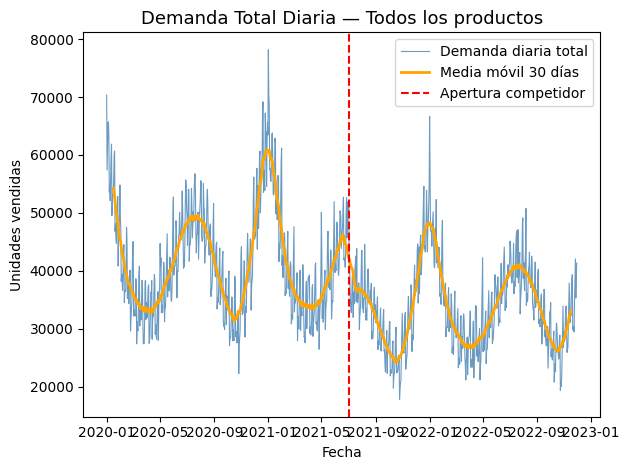

In [18]:
# ── Línea vertical: apertura del competidor ──
COMPETIDOR_DATE = pd.Timestamp('2021-07-02')

fig, ax = plt.subplots()
ax.plot(demanda_diaria['date'], demanda_diaria['demanda_total'],
        color='steelblue', linewidth=0.8, alpha=0.8, label='Demanda diaria total')

# Media móvil de 30 días para suavizar la tendencia
demanda_diaria['ma30'] = demanda_diaria['demanda_total'].rolling(30, center=True).mean()
ax.plot(demanda_diaria['date'], demanda_diaria['ma30'],
        color='orange', linewidth=2, label='Media móvil 30 días')

ax.axvline(COMPETIDOR_DATE, color='red', linestyle='--', linewidth=1.5, label='Apertura competidor')
ax.set_title('Demanda Total Diaria — Todos los productos', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades vendidas')
ax.legend()
plt.tight_layout()
plt.show()

## Distribución de la demanda por categoria 

In [19]:
df_demanda.columns

Index(['date', 'id_producto', 'demanda'], dtype='str')

In [20]:
df_catalogo.columns

Index(['id_producto', 'categoria', 'subcategoria', 'tamaño', 'premium',
       'marca_exclusiva', 'estacional', 'nit_proveedor'],
      dtype='str')

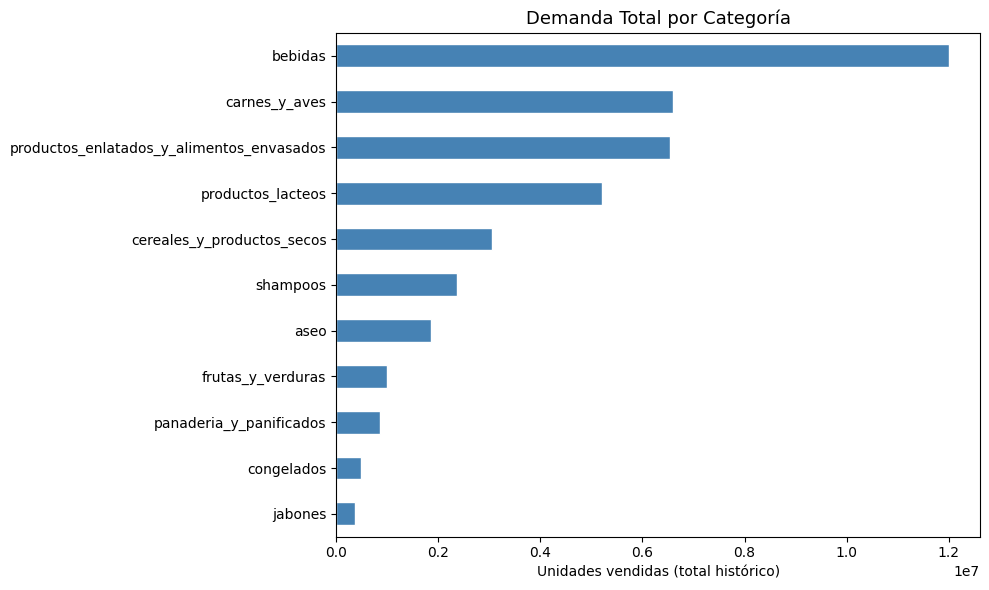

In [21]:
## unir catalogo con demanda, para analizar la distribución 

df_cat_demanda= df_demanda.merge(df_catalogo, on='id_producto',how='left')

## demanda total por categoria

dem_cat= df_cat_demanda.groupby('categoria')['demanda'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
dem_cat.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Demanda Total por Categoría', fontsize=13)
ax.set_xlabel('Unidades vendidas (total histórico)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Estacionalidad mensual

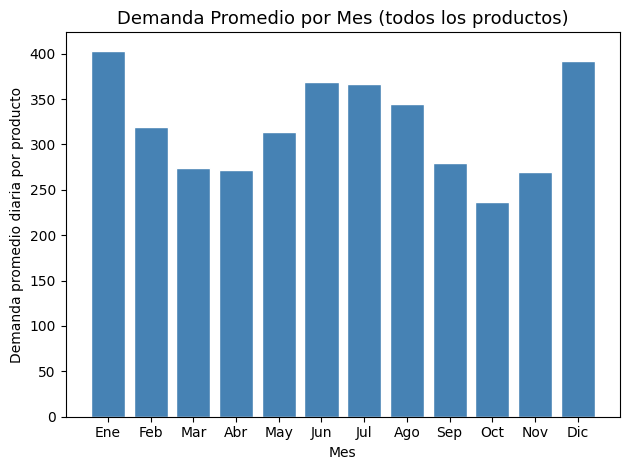

In [22]:
df_demanda['Mes']=df_demanda['date'].dt.month
dem_mes= df_demanda.groupby('Mes')['demanda'].mean()
meses_nombre = ['Ene','Feb','Mar','Abr','May','Jun',
                'Jul','Ago','Sep','Oct','Nov','Dic']
fig, ax = plt.subplots()
ax.bar(range(1,13), dem_mes.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(1,13))
ax.set_xticklabels(meses_nombre)
ax.set_title('Demanda Promedio por Mes (todos los productos)', fontsize=13)
ax.set_xlabel('Mes')
ax.set_ylabel('Demanda promedio diaria por producto')
plt.tight_layout()
plt.show()

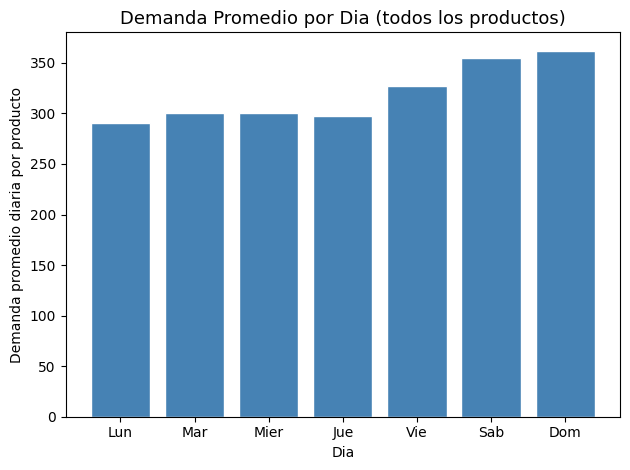

In [24]:
df_demanda['Dia']=df_demanda['date'].dt.day_of_week
dem_dia= df_demanda.groupby('Dia')['demanda'].mean()
dias_nombre= ['Lun','Mar','Mier','Jue','Vie','Sab','Dom']
fig, ax = plt.subplots()
ax.bar(range(7), dem_dia.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(dias_nombre)
ax.set_title('Demanda Promedio por Dia (todos los productos)', fontsize=13)
ax.set_xlabel('Dia')
ax.set_ylabel('Demanda promedio diaria por producto')
plt.tight_layout()
plt.show()

## Revisión de valores nulos

In [25]:
nulos=df_demanda.isnull().sum()
porcentajenulos=(nulos/len(df_demanda))*100
df_nulos= pd.DataFrame({
    'columna':nulos.index,
    'valores_nulos':nulos.values,
    'porcentaje':porcentajenulos.values
})

In [26]:
print(df_nulos)

       columna  valores_nulos  porcentaje
0         date              0         0.0
1  id_producto              0         0.0
2      demanda              0         0.0
3          Mes              0         0.0
4          Dia              0         0.0


In [27]:
nuloscatalogo=df_catalogo.isnull().sum()
porcentajenulos=(nuloscatalogo/len(df_catalogo))*100
df_nulos= pd.DataFrame({
    'columna':nuloscatalogo.index,
    'valores_nulos':nuloscatalogo.values,
    'porcentaje':porcentajenulos.values
})

In [28]:
print(df_nulos)

           columna  valores_nulos  porcentaje
0      id_producto              0    0.000000
1        categoria              0    0.000000
2     subcategoria             32   23.703704
3           tamaño              3    2.222222
4          premium              5    3.703704
5  marca_exclusiva              0    0.000000
6       estacional              0    0.000000
7    nit_proveedor              1    0.740741


## Impacto del ingreso del competidor

In [29]:
# ── Línea vertical: apertura del competidor ──
COMPETIDOR_DATE = pd.Timestamp('2021-07-02')
ventana_meses = 6

inicio_pre  = COMPETIDOR_DATE - pd.DateOffset(months=ventana_meses)
inicio_post = COMPETIDOR_DATE
fin_post    = COMPETIDOR_DATE + pd.DateOffset(months=ventana_meses)



In [30]:
#filtros de la demanda

pre=demanda_diaria[(demanda_diaria['date']>=inicio_pre) & (demanda_diaria['date']< COMPETIDOR_DATE)]
post=demanda_diaria[(demanda_diaria['date']>=inicio_post) & (demanda_diaria['date']< fin_post)]

In [32]:
media_pre = pre['demanda_total'].mean()
media_post = post['demanda_total'].mean()

In [31]:
demanda_diaria.columns

Index(['date', 'demanda_total', 'ma30'], dtype='str')

In [33]:
impacto_pct = (media_post-media_pre)/media_pre*100
impacto_abs = media_post-media_pre

In [34]:
print(f" Período ANTES  ({inicio_pre.date()} → {COMPETIDOR_DATE.date()})")
print(f"   Demanda diaria promedio: {media_pre:,.0f} unidades")
print()
print(f" Período DESPUÉS ({COMPETIDOR_DATE.date()} → {fin_post.date()})")
print(f"   Demanda diaria promedio: {media_post:,.0f} unidades")
print()
print(f" Impacto absoluto:    {impacto_abs:,.0f} unidades/día menos")
print(f" Impacto porcentual:  {impacto_pct:.1f}%")

 Período ANTES  (2021-01-02 → 2021-07-02)
   Demanda diaria promedio: 41,170 unidades

 Período DESPUÉS (2021-07-02 → 2022-01-02)
   Demanda diaria promedio: 33,671 unidades

 Impacto absoluto:    -7,499 unidades/día menos
 Impacto porcentual:  -18.2%


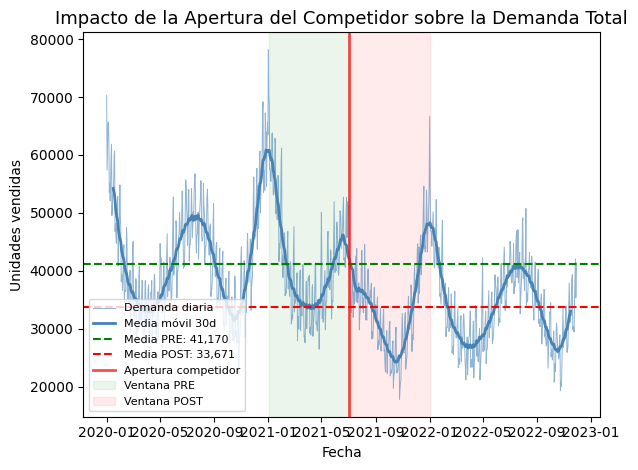


 Conclusión: La apertura del competidor redujo la demanda diaria promedio
   en ~18.2% (7,499 unidades/día menos).


In [35]:
# ── Visualización del impacto ──
fig, ax = plt.subplots()

ax.plot(demanda_diaria['date'], demanda_diaria['demanda_total'],
        color='steelblue', linewidth=0.7, alpha=0.6, label='Demanda diaria')
ax.plot(demanda_diaria['date'], demanda_diaria['ma30'],
        color='steelblue', linewidth=2, label='Media móvil 30d')

# Líneas de medias antes/después
ax.axhline(media_pre,  color='green', linestyle='--', linewidth=1.5,
           label=f'Media PRE: {media_pre:,.0f}')
ax.axhline(media_post, color='red',   linestyle='--', linewidth=1.5,
           label=f'Media POST: {media_post:,.0f}')

ax.axvline(COMPETIDOR_DATE, color='red', linestyle='-', linewidth=2,
           alpha=0.7, label='Apertura competidor')

# Sombreado de ventanas
ax.axvspan(inicio_pre, COMPETIDOR_DATE, alpha=0.08, color='green', label='Ventana PRE')
ax.axvspan(COMPETIDOR_DATE, fin_post,   alpha=0.08, color='red',   label='Ventana POST')

ax.set_title('Impacto de la Apertura del Competidor sobre la Demanda Total', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades vendidas')
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\n Conclusión: La apertura del competidor redujo la demanda diaria promedio")
print(f"   en ~{abs(impacto_pct):.1f}% ({abs(impacto_abs):,.0f} unidades/día menos).")

In [ ]:
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error